# Late Delivery Risk Prediction for Supply Chain Orders

## Business Problem

Late deliveries can affect customer satisfaction, operational planning, and
supply-chain efficiency. The objective of this project is to predict whether
an order is at risk of late delivery using information available around the
time the order is placed.

The target variable is:

- **1 — Late delivery**
- **0 — Not late**

The project uses the DataCo Supply Chain dataset containing approximately
180,000 line-item records from more than 65,000 unique orders.

## Project Objectives

The analysis focuses on:

- preventing target and future-information leakage;
- handling multiple line-item records belonging to the same order;
- comparing several classification algorithms;
- selecting and tuning the model using a separate validation set;
- evaluating the final model on an untouched test set;
- interpreting predictions using SHAP.

## Final Model

The selected model was a tuned **Gradient Boosting Classifier**.

Final untouched test performance:

- **ROC-AUC: 0.7710**
- **Precision: 0.7076**
- **Recall: 0.7058**
- **F1-score: 0.7067**

A secondary Order-ID-level robustness evaluation produced a
**ROC-AUC of 0.7728**, closely matching the row-level result.

In [1]:
%pip install xgboost

%pip install shap -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/tokenized_access_logs.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv
/kaggle/input/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis/DescriptionDataCoSupplyChain.csv


In [3]:
import numpy as np
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/shashwatwork/"
    "dataco-smart-supply-chain-for-big-data-analysis/"
    "DataCoSupplyChainDataset.csv",
    encoding="latin-1"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (180519, 53)


In [4]:
print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

First 5 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping

In [5]:
# Missing-value summary
missing_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing_summary = missing_summary[missing_summary > 0]

print("Columns with missing values:")
display(
    pd.DataFrame({
        "Missing Count": missing_summary,
        "Missing %": (missing_summary / len(df) * 100).round(2)
    })
)

# Target distribution
print("\nTarget distribution:")
target_summary = pd.DataFrame({
    "Count": df["Late_delivery_risk"].value_counts(),
    "Percentage": (
        df["Late_delivery_risk"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(target_summary)

Columns with missing values:


,Missing Count,Missing %
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00



Target distribution:


,Count,Percentage
Late_delivery_risk,,
1,98977,54.83
0,81542,45.17


## Target Leakage Audit

Before modeling, potentially problematic features were examined to determine
whether they contained information that would only become available after
the delivery outcome was known.

Two particularly strong leakage signals were identified:

- **Days for shipping (real):** comparing actual shipping duration with the
  scheduled duration reproduced the late-delivery target for approximately
  **97.55%** of records.
- **Delivery Status:** directly revealed whether an order was classified as
  a late delivery.

The shipping date also represents future information because it is only known
after shipment occurs.

`Order Status` was excluded because the intended prediction point is around
order placement / pre-dispatch, and some status values may reflect information
that develops later in the order lifecycle.

These variables were therefore excluded from the predictive feature set to
avoid artificially inflated model performance.

In [6]:
# Check whether the target can be reconstructed from actual shipping duration
derived_late_risk = (
    df["Days for shipping (real)"]
    > df["Days for shipment (scheduled)"]
).astype(int)

target_match = (
    derived_late_risk == df["Late_delivery_risk"]
).mean()

print(
    f"Target reproduced using actual vs scheduled shipping days: "
    f"{target_match:.2%}"
)

# Check relationship between Delivery Status and the target
print("\nDelivery Status vs Late Delivery Risk:")
display(
    pd.crosstab(
        df["Delivery Status"],
        df["Late_delivery_risk"],
        normalize="index"
    ).round(3)
)

# Inspect Order Status values
print("\nOrder Status values:")
print(df["Order Status"].value_counts())

# Display the two date columns
print("\nExample order and shipping dates:")
display(
    df[
        [
            "order date (DateOrders)",
            "shipping date (DateOrders)"
        ]
    ].head()
)

Target reproduced using actual vs scheduled shipping days: 97.55%

Delivery Status vs Late Delivery Risk:


Late_delivery_risk,0,1
Delivery Status,,
Advance shipping,1.0,0.0
Late delivery,0.0,1.0
Shipping canceled,1.0,0.0
Shipping on time,1.0,0.0



Order Status values:
Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

Example order and shipping dates:


,order date (DateOrders),shipping date (DateOrders)
0,1/31/2018 22:56,2/3/2018 22:56
1,1/13/2018 12:27,1/18/2018 12:27
2,1/13/2018 12:06,1/17/2018 12:06
3,1/13/2018 11:45,1/16/2018 11:45
4,1/13/2018 11:24,1/15/2018 11:24


In [7]:
order_counts = df["Order Id"].value_counts()

print("Total rows:", len(df))
print("Unique Order IDs:", df["Order Id"].nunique())

print(
    "Orders appearing more than once:",
    (order_counts > 1).sum()
)

print(
    "Rows belonging to repeated orders:",
    order_counts[order_counts > 1].sum()
)

print(
    "Maximum rows for a single Order ID:",
    order_counts.max()
)

# Check whether repeated rows for the same order have the same target
target_per_order = (
    df.groupby("Order Id")["Late_delivery_risk"]
      .nunique()
)

print(
    "Orders containing more than one target value:",
    (target_per_order > 1).sum()
)


Total rows: 180519
Unique Order IDs: 65752
Orders appearing more than once: 45902
Rows belonging to repeated orders: 160669
Maximum rows for a single Order ID: 5
Orders containing more than one target value: 0


## Experimental Design

A key challenge in this dataset is that a single order may contain multiple
line-item records. If rows from the same order appear in both training and
evaluation data, model performance can be artificially optimistic.

To prevent this, the dataset was split using **Order ID as the grouping unit**.

The split was performed as:

- **60% Training**
- **20% Validation**
- **20% Test**

The split was also stratified by the late-delivery target to maintain a
similar class distribution across all three partitions.

### Role of Each Partition

- **Training set:** used to learn preprocessing rules and fit models.
- **Validation set:** used to compare models, tune hyperparameters, and select
  the classification threshold.
- **Test set:** kept untouched until all modeling decisions were finalized.

All learned preprocessing steps, including categorical count encoding, were
derived exclusively from the training data and then applied unchanged to
validation and test data.

This design reduces data leakage and provides a more reliable estimate of
generalization to unseen orders.

In [8]:
from sklearn.model_selection import train_test_split

# One row per unique order
order_level = (
    df[["Order Id", "Late_delivery_risk"]]
    .drop_duplicates()
)

print("Total unique orders:", len(order_level))


# Step 1: 60% train, 40% temporary
train_orders, temp_orders = train_test_split(
    order_level,
    test_size=0.40,
    random_state=42,
    stratify=order_level["Late_delivery_risk"]
)


# Step 2: Split temporary 40% into:
# 20% validation + 20% test
val_orders, test_orders = train_test_split(
    temp_orders,
    test_size=0.50,
    random_state=42,
    stratify=temp_orders["Late_delivery_risk"]
)


# Bring back all rows belonging to each Order Id
train_df = df[
    df["Order Id"].isin(train_orders["Order Id"])
].copy()

val_df = df[
    df["Order Id"].isin(val_orders["Order Id"])
].copy()

test_df = df[
    df["Order Id"].isin(test_orders["Order Id"])
].copy()



# Basic checks
print("\nROW COUNTS")
print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))


print("\nUNIQUE ORDER COUNTS")
print("Train orders:", train_df["Order Id"].nunique())
print("Validation orders:", val_df["Order Id"].nunique())
print("Test orders:", test_df["Order Id"].nunique())


# Make sure orders do NOT overlap
train_ids = set(train_df["Order Id"])
val_ids = set(val_df["Order Id"])
test_ids = set(test_df["Order Id"])

print("\nORDER ID OVERLAP")
print(
    "Train / Validation:",
    len(train_ids & val_ids)
)

print(
    "Train / Test:",
    len(train_ids & test_ids)
)

print(
    "Validation / Test:",
    len(val_ids & test_ids)
)


# Check target balance
print("\nTRAIN TARGET DISTRIBUTION")
print(
    train_df["Late_delivery_risk"]
    .value_counts(normalize=True)
    .round(4)
)

print("\nVALIDATION TARGET DISTRIBUTION")
print(
    val_df["Late_delivery_risk"]
    .value_counts(normalize=True)
    .round(4)
)

print("\nTEST TARGET DISTRIBUTION")
print(
    test_df["Late_delivery_risk"]
    .value_counts(normalize=True)
    .round(4)
)

Total unique orders: 65752

ROW COUNTS
Train rows: 108215
Validation rows: 35933
Test rows: 36371

UNIQUE ORDER COUNTS
Train orders: 39451
Validation orders: 13150
Test orders: 13151

ORDER ID OVERLAP
Train / Validation: 0
Train / Test: 0
Validation / Test: 0

TRAIN TARGET DISTRIBUTION
Late_delivery_risk
1    0.5496
0    0.4504
Name: proportion, dtype: float64

VALIDATION TARGET DISTRIBUTION
Late_delivery_risk
1    0.5466
0    0.4534
Name: proportion, dtype: float64

TEST TARGET DISTRIBUTION
Late_delivery_risk
1    0.5462
0    0.4538
Name: proportion, dtype: float64


## Feature Selection and Preprocessing

Feature selection was performed based on the intended prediction point and
the usefulness of each variable for generalization.

### Removed Features

The following groups of variables were excluded:

- **Target leakage / future information:** delivery status, actual shipping
  duration, shipping date, and order status.
- **Highly missing or unusable features:** Product Description and Order
  Zipcode.
- **Identifiers and personal information:** customer IDs, order IDs,
  line-item IDs, names, email, password, street address, product IDs,
  and similar identifier fields.

`Order ID` was retained temporarily for creating group-safe train,
validation, and test partitions, but was removed before model training.

### Date Feature Engineering

The original order timestamp was converted into:

- `order_month`
- `order_dayofweek`
- `order_hour`

The raw timestamp was then removed.

### Categorical Encoding

Several categorical variables had high cardinality, including thousands of
unique order cities and states. Instead of expanding them using one-hot
encoding, **count encoding** was used.

For every categorical feature, category counts were learned from the
training set only. The same mappings were then applied to validation and
test data. Categories not observed during training were assigned a value
of zero.

### Final Data Quality Checks

Before modeling, the processed datasets were checked for:

- missing values;
- infinite values;
- non-numeric columns;
- inconsistent feature sets across partitions;
- constant features.

`Product Status` was identified as constant in the training data and was
removed.

The final modeling dataset contained **31 features**.

In [9]:

# Separate target
y_train = train_df["Late_delivery_risk"].copy()
y_val = val_df["Late_delivery_risk"].copy()
y_test = test_df["Late_delivery_risk"].copy()


# 1. Leakage / future-information columns
leakage_cols = [
    "Delivery Status",
    "Days for shipping (real)",
    "Order Status",
    "shipping date (DateOrders)"
]

# 2. Unusable / heavily missing columns


unusable_cols = [
    "Product Description",
    "Order Zipcode"
]


# 3. Identifiers / personal information

identifier_cols = [
    "Customer Email",
    "Customer Fname",
    "Customer Lname",
    "Customer Password",
    "Customer Street",
    "Customer Id",
    "Order Id",
    "Order Customer Id",
    "Order Item Id",
    "Order Item Cardprod Id",
    "Product Card Id",
    "Category Id",
    "Department Id",
    "Product Category Id",
    "Product Image",
    "Customer Zipcode"
]


drop_cols = (
    leakage_cols
    + unusable_cols
    + identifier_cols
)



# Create raw feature datasets

X_train_raw = train_df.drop(
    columns=drop_cols + ["Late_delivery_risk"]
).copy()

X_val_raw = val_df.drop(
    columns=drop_cols + ["Late_delivery_risk"]
).copy()

X_test_raw = test_df.drop(
    columns=drop_cols + ["Late_delivery_risk"]
).copy()


# Check shapes

print("Training feature shape:", X_train_raw.shape)
print("Validation feature shape:", X_val_raw.shape)
print("Test feature shape:", X_test_raw.shape)

print("\nNumber of target values:")
print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

print("\nRemaining features:")
print(X_train_raw.columns.tolist())

Training feature shape: (108215, 30)
Validation feature shape: (35933, 30)
Test feature shape: (36371, 30)

Number of target values:
Train: 108215
Validation: 35933
Test: 36371

Remaining features:
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Product Name', 'Product Price', 'Product Status', 'Shipping Mode']


In [10]:
# Convert order date to datetime
X_train_raw["order date (DateOrders)"] = pd.to_datetime(
    X_train_raw["order date (DateOrders)"]
)

X_val_raw["order date (DateOrders)"] = pd.to_datetime(
    X_val_raw["order date (DateOrders)"]
)

X_test_raw["order date (DateOrders)"] = pd.to_datetime(
    X_test_raw["order date (DateOrders)"]
)

# Create date features
for data in [
    X_train_raw,
    X_val_raw,
    X_test_raw
]:
    data["order_month"] = data["order date (DateOrders)"].dt.month
    data["order_dayofweek"] = data["order date (DateOrders)"].dt.dayofweek
    data["order_hour"] = data["order date (DateOrders)"].dt.hour

# Drop original datetime
X_train_raw = X_train_raw.drop(
    columns=["order date (DateOrders)"]
)

X_val_raw = X_val_raw.drop(
    columns=["order date (DateOrders)"]
)

X_test_raw = X_test_raw.drop(
    columns=["order date (DateOrders)"]
)

print(
    "Training shape after date feature engineering:",
    X_train_raw.shape
)

print(
    "Validation shape after date feature engineering:",
    X_val_raw.shape
)

print(
    "Test shape after date feature engineering:",
    X_test_raw.shape
)

print("\nCreated date features:")

display(
    X_train_raw[
        ["order_month", "order_dayofweek", "order_hour"]
    ].head()
)

Training shape after date feature engineering: (108215, 32)
Validation shape after date feature engineering: (35933, 32)
Test shape after date feature engineering: (36371, 32)

Created date features:


,order_month,order_dayofweek,order_hour
0,1,2,22
4,1,5,11
5,1,5,11
9,1,5,9
10,1,5,9


In [11]:




categorical_cols = X_train_raw.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_cols = X_train_raw.select_dtypes(
    include=["number"]
).columns.tolist()

print(
    "Number of categorical features:",
    len(categorical_cols)
)

print(
    "Number of numerical features:",
    len(numerical_cols)
)

print("\nCategorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Number of categorical features: 14
Number of numerical features: 18

Categorical features:
['Type', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State', 'Product Name', 'Shipping Mode']

Numerical features:
['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'Product Status', 'order_month', 'order_dayofweek', 'order_hour']


In [12]:
category_cardinality = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique Categories": [
        X_train_raw[col].nunique()
        for col in categorical_cols
    ]
}).sort_values(
    "Unique Categories",
    ascending=False
)

display(category_cardinality)

,Feature,Unique Categories
8,Order City,3409
11,Order State,1061
2,Customer City,563
9,Order Country,164
12,Product Name,118
1,Category Name,50
5,Customer State,45
10,Order Region,23
6,Department Name,11
7,Market,5


In [18]:
# Learn category counts from TRAINING data only

count_maps = {}

for col in categorical_cols:
    count_maps[col] = (
        X_train_raw[col]
        .value_counts()
        .to_dict()
    )


# Make encoded copies

X_train_encoded = X_train_raw.copy()
X_val_encoded = X_val_raw.copy()
X_test_encoded = X_test_raw.copy()


# Apply TRAIN mappings to all three datasets

for col in categorical_cols:
    mapping = count_maps[col]

    X_train_encoded[col] = (
        X_train_encoded[col]
        .map(mapping)
        .fillna(0)
    )

    X_val_encoded[col] = (
        X_val_encoded[col]
        .map(mapping)
        .fillna(0)
    )

    X_test_encoded[col] = (
        X_test_encoded[col]
        .map(mapping)
        .fillna(0)
    )


# Check results

print("Count encoding completed.")

print("\nTraining shape:", X_train_encoded.shape)
print("Validation shape:", X_val_encoded.shape)
print("Test shape:", X_test_encoded.shape)

print("\nCategorical columns remaining in TRAIN:")
print(
    X_train_encoded
    .select_dtypes(include=["object", "string"])
    .columns.tolist()
)

print("\nCategorical columns remaining in VALIDATION:")
print(
    X_val_encoded
    .select_dtypes(include=["object", "string"])
    .columns.tolist()
)

print("\nCategorical columns remaining in TEST:")
print(
    X_test_encoded
    .select_dtypes(include=["object", "string"])
    .columns.tolist()
)

Count encoding completed.

Training shape: (108215, 32)
Validation shape: (35933, 32)
Test shape: (36371, 32)

Categorical columns remaining in TRAIN:
[]

Categorical columns remaining in VALIDATION:
[]

Categorical columns remaining in TEST:
[]


In [19]:
print("Unseen categories in VALIDATION:\n")

for col in categorical_cols:

    unseen_mask = ~X_val_raw[col].isin(
        count_maps[col].keys()
    )

    unseen_count = unseen_mask.sum()

    if unseen_count > 0:
        print(
            f"{col}: {unseen_count} rows "
            f"({unseen_count / len(X_val_raw) * 100:.2f}%)"
        )


print("\nUnseen categories in TEST:\n")

for col in categorical_cols:

    unseen_mask = ~X_test_raw[col].isin(
        count_maps[col].keys()
    )

    unseen_count = unseen_mask.sum()

    if unseen_count > 0:
        print(
            f"{col}: {unseen_count} rows "
            f"({unseen_count / len(X_test_raw) * 100:.2f}%)"
        )

Unseen categories in VALIDATION:

Customer State: 1 rows (0.00%)
Order City: 456 rows (1.27%)
Order State: 62 rows (0.17%)

Unseen categories in TEST:

Order City: 384 rows (1.06%)
Order State: 65 rows (0.18%)


In [20]:
# 1. Missing values

print("MISSING VALUES")

print(
    "Train:",
    X_train_encoded.isnull().sum().sum()
)

print(
    "Validation:",
    X_val_encoded.isnull().sum().sum()
)

print(
    "Test:",
    X_test_encoded.isnull().sum().sum()
)

# 2. Infinite values
print("\nINFINITE VALUES")

print(
    "Train:",
    np.isinf(
        X_train_encoded.select_dtypes(include="number")
    ).sum().sum()
)

print(
    "Validation:",
    np.isinf(
        X_val_encoded.select_dtypes(include="number")
    ).sum().sum()
)

print(
    "Test:",
    np.isinf(
        X_test_encoded.select_dtypes(include="number")
    ).sum().sum()
)

# 3. Same columns in all three datasets

same_train_val = (
    X_train_encoded.columns.tolist()
    == X_val_encoded.columns.tolist()
)

same_train_test = (
    X_train_encoded.columns.tolist()
    == X_test_encoded.columns.tolist()
)

print("\nCOLUMN CHECK")

print(
    "Train / Validation identical:",
    same_train_val
)

print(
    "Train / Test identical:",
    same_train_test
)



# 4. Check non-numeric features

print("\nNON-NUMERIC FEATURES")

print(
    "Train:",
    X_train_encoded
    .select_dtypes(exclude="number")
    .columns.tolist()
)

print(
    "Validation:",
    X_val_encoded
    .select_dtypes(exclude="number")
    .columns.tolist()
)

print(
    "Test:",
    X_test_encoded
    .select_dtypes(exclude="number")
    .columns.tolist()
)



# 5. Constant features
# determining these from TRAIN only
constant_features = [
    col
    for col in X_train_encoded.columns
    if X_train_encoded[col].nunique() <= 1
]

print("\nCONSTANT FEATURES IN TRAIN:")
print(constant_features)

MISSING VALUES
Train: 0
Validation: 0
Test: 0

INFINITE VALUES
Train: 0
Validation: 0
Test: 0

COLUMN CHECK
Train / Validation identical: True
Train / Test identical: True

NON-NUMERIC FEATURES
Train: []
Validation: []
Test: []

CONSTANT FEATURES IN TRAIN:
['Product Status']


In [21]:
X_train_encoded = X_train_encoded.drop(
    columns=["Product Status"]
)

X_val_encoded = X_val_encoded.drop(
    columns=["Product Status"]
)

X_test_encoded = X_test_encoded.drop(
    columns=["Product Status"]
)

print("Training shape:", X_train_encoded.shape)
print("Validation shape:", X_val_encoded.shape)
print("Test shape:", X_test_encoded.shape)

print(
    "\nProduct Status still present in train:",
    "Product Status" in X_train_encoded.columns
)

print(
    "Product Status still present in validation:",
    "Product Status" in X_val_encoded.columns
)

print(
    "Product Status still present in test:",
    "Product Status" in X_test_encoded.columns
)

Training shape: (108215, 31)
Validation shape: (35933, 31)
Test shape: (36371, 31)

Product Status still present in train: False
Product Status still present in validation: False
Product Status still present in test: False


## Model Selection and Hyperparameter Tuning

Four classification models were compared using the validation set:

- Logistic Regression
- XGBoost
- Random Forest
- Gradient Boosting

**ROC-AUC was used as the primary model-selection metric** because it evaluates
how well the model ranks late-delivery risk across classification thresholds.

Logistic Regression was included as a simple linear baseline, while the
tree-based ensemble models were used to capture nonlinear relationships and
feature interactions.

### Validation Performance

| Model | Validation Accuracy | Validation ROC-AUC |
|---|---:|---:|
| Gradient Boosting | 0.7167 | **0.7752** |
| Random Forest | 0.7119 | 0.7705 |
| XGBoost | 0.7009 | 0.7618 |
| Logistic Regression | 0.6850 | 0.6862 |

Gradient Boosting achieved the highest validation ROC-AUC and was therefore
selected for further tuning.

### Hyperparameter Tuning

A small controlled search was performed over:

- number of estimators;
- learning rate;
- maximum tree depth.

The best configuration was:

- `n_estimators = 100`
- `learning_rate = 0.05`
- `max_depth = 3`

This produced a validation ROC-AUC of **0.7764**.

The improvement over the untuned Gradient Boosting model was modest
(0.7752 → 0.7764), suggesting that the baseline configuration was already
close to optimal within the tested search space.

In [22]:

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

# Train only on TRAIN
logistic_model.fit(
    X_train_encoded,
    y_train
)

# Evaluate on VALIDATION
logistic_val_pred = logistic_model.predict(
    X_val_encoded
)

logistic_val_prob = logistic_model.predict_proba(
    X_val_encoded
)[:, 1]

logistic_val_accuracy = accuracy_score(
    y_val,
    logistic_val_pred
)

logistic_val_auc = roc_auc_score(
    y_val,
    logistic_val_prob
)

print(
    f"Logistic Regression Validation Accuracy: "
    f"{logistic_val_accuracy:.4f}"
)

print(
    f"Logistic Regression Validation ROC-AUC: "
    f"{logistic_val_auc:.4f}"
)

Logistic Regression Validation Accuracy: 0.6850
Logistic Regression Validation ROC-AUC: 0.6862


In [23]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(
    X_train_encoded,
    y_train
)

xgb_val_pred = xgb_model.predict(
    X_val_encoded
)

xgb_val_prob = xgb_model.predict_proba(
    X_val_encoded
)[:, 1]

xgb_val_accuracy = accuracy_score(
    y_val,
    xgb_val_pred
)

xgb_val_auc = roc_auc_score(
    y_val,
    xgb_val_prob
)

print(
    f"XGBoost Validation Accuracy: "
    f"{xgb_val_accuracy:.4f}"
)

print(
    f"XGBoost Validation ROC-AUC: "
    f"{xgb_val_auc:.4f}"
)

XGBoost Validation Accuracy: 0.6936
XGBoost Validation ROC-AUC: 0.7600


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_encoded,
    y_train
)

rf_val_pred = rf_model.predict(
    X_val_encoded
)

rf_val_prob = rf_model.predict_proba(
    X_val_encoded
)[:, 1]

rf_val_accuracy = accuracy_score(
    y_val,
    rf_val_pred
)

rf_val_auc = roc_auc_score(
    y_val,
    rf_val_prob
)

print(
    f"Random Forest Validation Accuracy: "
    f"{rf_val_accuracy:.4f}"
)

print(
    f"Random Forest Validation ROC-AUC: "
    f"{rf_val_auc:.4f}"
)

Random Forest Validation Accuracy: 0.7119
Random Forest Validation ROC-AUC: 0.7705


In [25]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train_encoded,
    y_train
)

gb_val_pred = gb_model.predict(
    X_val_encoded
)

gb_val_prob = gb_model.predict_proba(
    X_val_encoded
)[:, 1]

gb_val_accuracy = accuracy_score(
    y_val,
    gb_val_pred
)

gb_val_auc = roc_auc_score(
    y_val,
    gb_val_prob
)

print(
    f"Gradient Boosting Validation Accuracy: "
    f"{gb_val_accuracy:.4f}"
)

print(
    f"Gradient Boosting Validation ROC-AUC: "
    f"{gb_val_auc:.4f}"
)

Gradient Boosting Validation Accuracy: 0.7167
Gradient Boosting Validation ROC-AUC: 0.7752


In [26]:
validation_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Validation Accuracy": [
        logistic_val_accuracy,
        xgb_val_accuracy,
        rf_val_accuracy,
        gb_val_accuracy
    ],
    "Validation ROC-AUC": [
        logistic_val_auc,
        xgb_val_auc,
        rf_val_auc,
        gb_val_auc
    ]
})

validation_results = (
    validation_results
    .sort_values(
        by="Validation ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    validation_results.style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation ROC-AUC": "{:.4f}"
    })
)

,Model,Validation Accuracy,Validation ROC-AUC
0,Gradient Boosting,0.7167,0.7752
1,Random Forest,0.7119,0.7705
2,XGBoost,0.6936,0.7600
3,Logistic Regression,0.6850,0.6862


In [27]:
from sklearn.model_selection import ParameterGrid
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.10],
    "max_depth": [2, 3]
}

tuning_results = []

best_gb_model = None
best_gb_params = None
best_gb_val_auc = -1

for params in ParameterGrid(param_grid):

    model = GradientBoostingClassifier(
        random_state=42,
        **params
    )

    model.fit(
        X_train_encoded,
        y_train
    )

    val_prob = model.predict_proba(
        X_val_encoded
    )[:, 1]

    val_pred = model.predict(
        X_val_encoded
    )

    val_auc = roc_auc_score(
        y_val,
        val_prob
    )

    val_accuracy = accuracy_score(
        y_val,
        val_pred
    )

    tuning_results.append({
        "n_estimators": params["n_estimators"],
        "learning_rate": params["learning_rate"],
        "max_depth": params["max_depth"],
        "Validation Accuracy": val_accuracy,
        "Validation ROC-AUC": val_auc
    })

    if val_auc > best_gb_val_auc:
        best_gb_val_auc = val_auc
        best_gb_params = params
        best_gb_model = model


tuning_results_df = pd.DataFrame(
    tuning_results
).sort_values(
    "Validation ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    tuning_results_df.style.format({
        "learning_rate": "{:.2f}",
        "Validation Accuracy": "{:.4f}",
        "Validation ROC-AUC": "{:.4f}"
    })
)

print("\nBest parameters:")
print(best_gb_params)

print(
    f"\nBest Validation ROC-AUC: "
    f"{best_gb_val_auc:.4f}"
)

,n_estimators,learning_rate,max_depth,Validation Accuracy,Validation ROC-AUC
0,100,0.05,3,0.7172,0.7764
1,100,0.10,3,0.7167,0.7752
2,200,0.05,3,0.7167,0.7746
3,200,0.10,2,0.7173,0.7734
4,200,0.10,3,0.7160,0.7734
5,100,0.10,2,0.7171,0.7725
6,200,0.05,2,0.7172,0.7725
7,100,0.05,2,0.7176,0.7704



Best parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Best Validation ROC-AUC: 0.7764


In [28]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

# Predictions at the default 0.50 threshold
best_gb_val_prob = best_gb_model.predict_proba(
    X_val_encoded
)[:, 1]

best_gb_val_pred = (
    best_gb_val_prob >= 0.50
).astype(int)

val_precision = precision_score(
    y_val,
    best_gb_val_pred
)

val_recall = recall_score(
    y_val,
    best_gb_val_pred
)

val_f1 = f1_score(
    y_val,
    best_gb_val_pred
)

print(f"Validation Precision: {val_precision:.4f}")
print(f"Validation Recall:    {val_recall:.4f}")
print(f"Validation F1-score:  {val_f1:.4f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        best_gb_val_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        best_gb_val_pred,
        digits=4
    )
)


Validation Precision: 0.8532
Validation Recall:    0.5828
Validation F1-score:  0.6926

Confusion Matrix:
[[14323  1970]
 [ 8193 11447]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6361    0.8791    0.7381     16293
           1     0.8532    0.5828    0.6926     19640

    accuracy                         0.7172     35933
   macro avg     0.7446    0.7310    0.7153     35933
weighted avg     0.7548    0.7172    0.7132     35933



## Classification Threshold Selection

The model outputs a probability of late delivery. A probability threshold is
then required to convert that probability into a class prediction.

The default threshold of `0.50` produced relatively high precision but lower
recall, meaning that many predicted late deliveries were correct, but a
substantial number of actual late deliveries were missed.

Because no explicit business cost function was available, several thresholds
were compared using the validation set.

A threshold of **0.40** was selected because it provided a more balanced
precision-recall trade-off:

- Precision: **0.7221**
- Recall: **0.7047**
- F1-score: **0.7133**
- Accuracy: **0.6904**

The threshold was selected using validation data only and then kept fixed for
the final test evaluation.

In [29]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds:

    val_pred_threshold = (
        best_gb_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,

        "Accuracy": accuracy_score(
            y_val,
            val_pred_threshold
        ),

        "Precision": precision_score(
            y_val,
            val_pred_threshold
        ),

        "Recall": recall_score(
            y_val,
            val_pred_threshold
        ),

        "F1": f1_score(
            y_val,
            val_pred_threshold
        )
    })


threshold_results_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_results_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.5798,0.5655,0.9980,0.7219
1,0.35,0.6001,0.5812,0.9605,0.7242
2,0.40,0.6904,0.7221,0.7047,0.7133
3,0.45,0.7165,0.8502,0.5842,0.6925
4,0.50,0.7172,0.8532,0.5828,0.6926
5,0.55,0.7176,0.8543,0.5826,0.6928
6,0.60,0.7176,0.8543,0.5826,0.6928


In [30]:
selected_threshold = 0.40

final_val_pred = (
    best_gb_val_prob >= selected_threshold
).astype(int)

print("Selected threshold:", selected_threshold)

print(
    f"Validation Accuracy:  "
    f"{accuracy_score(y_val, final_val_pred):.4f}"
)

print(
    f"Validation Precision: "
    f"{precision_score(y_val, final_val_pred):.4f}"
)

print(
    f"Validation Recall:    "
    f"{recall_score(y_val, final_val_pred):.4f}"
)

print(
    f"Validation F1-score:  "
    f"{f1_score(y_val, final_val_pred):.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_val,
        final_val_pred
    )
)

Selected threshold: 0.4
Validation Accuracy:  0.6904
Validation Precision: 0.7221
Validation Recall:    0.7047
Validation F1-score:  0.7133

Confusion Matrix:
[[10968  5325]
 [ 5800 13840]]


## Final Test Evaluation

After model selection, hyperparameter tuning, and threshold selection were
completed using the training and validation sets, the final model was
evaluated once on the untouched test set.

The classification threshold was fixed at **0.40** before test evaluation.

### Final Test Performance

- **ROC-AUC: 0.7710**
- **Accuracy: 0.6800**
- **Precision: 0.7076**
- **Recall: 0.7058**
- **F1-score: 0.7067**

The small difference between validation ROC-AUC (**0.7764**) and test
ROC-AUC (**0.7710**) indicates that model performance remained stable on
unseen orders.

The test set was not used for model selection, tuning, feature engineering,
or threshold adjustment.

In [31]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Final predictions on untouched TEST set

test_prob = best_gb_model.predict_proba(
    X_test_encoded
)[:, 1]

test_pred = (
    test_prob >= selected_threshold
).astype(int)

# Final metrics
test_auc = roc_auc_score(
    y_test,
    test_prob
)

test_accuracy = accuracy_score(
    y_test,
    test_pred
)

test_precision = precision_score(
    y_test,
    test_pred
)

test_recall = recall_score(
    y_test,
    test_pred
)

test_f1 = f1_score(
    y_test,
    test_pred
)


print("FINAL TEST RESULTS")
print("------------------")

print(
    f"ROC-AUC:   {test_auc:.4f}"
)

print(
    f"Accuracy:  {test_accuracy:.4f}"
)

print(
    f"Precision: {test_precision:.4f}"
)

print(
    f"Recall:    {test_recall:.4f}"
)

print(
    f"F1-score:  {test_f1:.4f}"
)


print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        test_pred
    )
)


print("\nClassification Report:")

print(
    classification_report(
        y_test,
        test_pred,
        digits=4
    )
)

FINAL TEST RESULTS
------------------
ROC-AUC:   0.7710
Accuracy:  0.6800
Precision: 0.7076
Recall:    0.7058
F1-score:  0.7067

Confusion Matrix:
[[10711  5793]
 [ 5845 14022]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6470    0.6490    0.6480     16504
           1     0.7076    0.7058    0.7067     19867

    accuracy                         0.6800     36371
   macro avg     0.6773    0.6774    0.6773     36371
weighted avg     0.6801    0.6800    0.6801     36371



## Model Interpretation

After final model evaluation, feature importance and SHAP were used to
understand which variables contributed most strongly to the model's
predictions.

Two complementary interpretation methods were used:

- **Gradient Boosting feature importance:** measures how useful each feature
  was for splitting observations across the ensemble.
- **SHAP values:** estimate how individual features contributed to model
  predictions across observations.

SHAP values are interpreted as model contributions rather than causal effects.
A positive SHAP value pushes the model output toward late delivery, while a
negative value pushes it toward the non-late class.

Because categorical variables were count-encoded, SHAP values for those
features were mapped back to their original category labels for more
meaningful interpretation.

Top 15 most important features:


,Feature,Importance
0,Days for shipment (scheduled),0.3969
1,Shipping Mode,0.3859
2,order_hour,0.1784
3,Type,0.0256
4,Latitude,0.0047
5,Longitude,0.0026
6,Order State,0.0014
7,Order City,0.0010
8,Order Region,0.0008
9,Customer City,0.0007


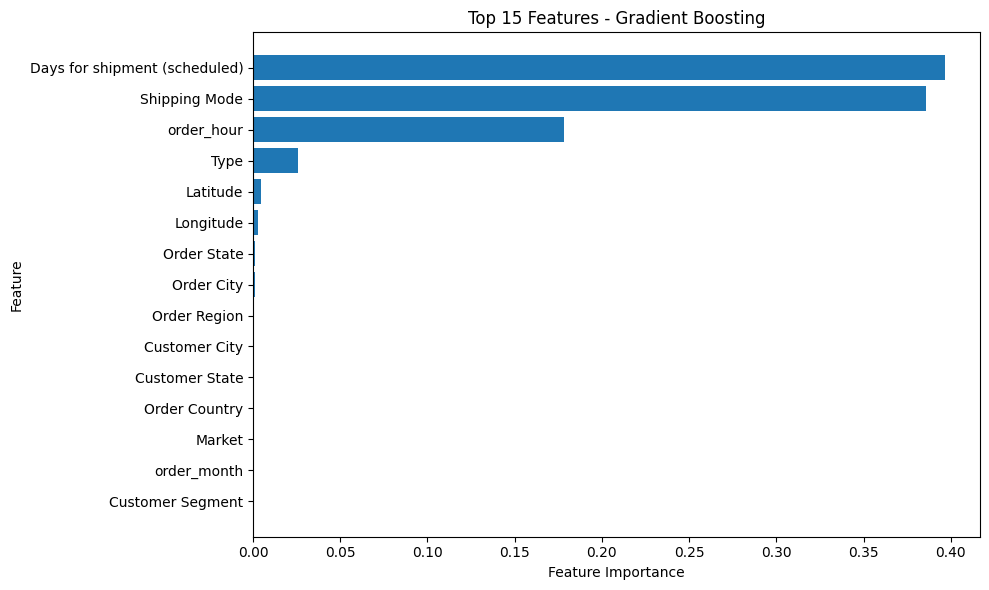

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": best_gb_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 15 most important features:")
display(
    feature_importance.head(15).style.format({
        "Importance": "{:.4f}"
    })
)

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features - Gradient Boosting"
)

plt.tight_layout()
plt.show()

In [34]:
import shap
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [35]:
# Sample test observations for SHAP analysis
X_shap = X_test_encoded.sample(
    n=min(5000, len(X_test_encoded)),
    random_state=42
)

# Build SHAP explainer for the selected Gradient Boosting model
explainer = shap.TreeExplainer(
    best_gb_model
)

# Calculate SHAP values
shap_values = explainer.shap_values(
    X_shap
)

print("SHAP sample shape:", X_shap.shape)
print("SHAP values shape:", shap_values.shape)

SHAP sample shape: (5000, 31)
SHAP values shape: (5000, 31)


,Feature,Mean |SHAP|
0,Days for shipment (scheduled),0.6129
1,Shipping Mode,0.5659
2,Type,0.2111
3,order_hour,0.1570
4,Latitude,0.0135
5,Order Region,0.0059
6,Order State,0.0059
7,Longitude,0.0059
8,Order City,0.0055
9,Order Country,0.0043


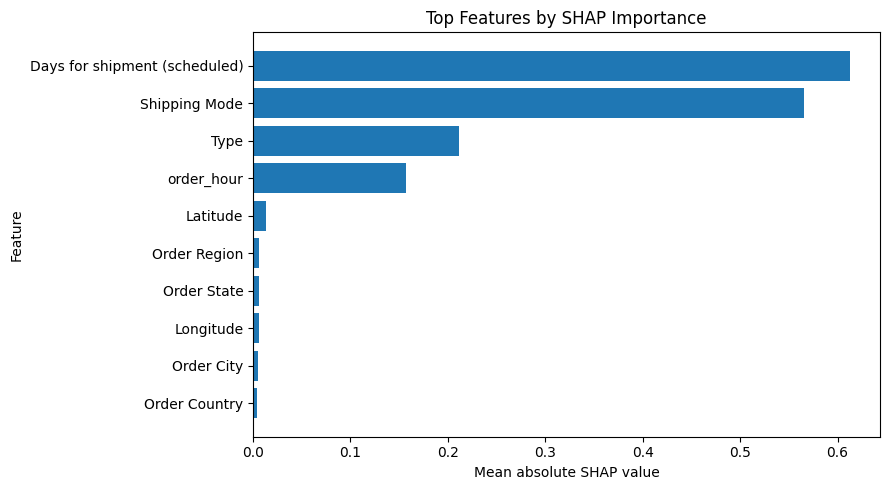

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mean absolute SHAP value for each feature
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean |SHAP|",
        ascending=False
    )
    .reset_index(drop=True)
)

# Show top 10
display(
    shap_importance.head(10).style.format({
        "Mean |SHAP|": "{:.4f}"
    })
)

# Plot top 10
top_shap = shap_importance.head(10)

plt.figure(figsize=(9, 5))

plt.barh(
    top_shap["Feature"][::-1],
    top_shap["Mean |SHAP|"][::-1]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Top Features by SHAP Importance")

plt.tight_layout()
plt.show()

In [37]:
# Position of Shipping Mode in the SHAP matrix
shipping_idx = X_shap.columns.get_loc(
    "Shipping Mode"
)

# Original shipping mode labels for the same sampled rows
shipping_analysis = pd.DataFrame({
    "Shipping Mode": X_test_raw.loc[
        X_shap.index,
        "Shipping Mode"
    ],

    "Shipping Mode SHAP": shap_values[
        :,
        shipping_idx
    ]
})

shipping_mode_effect = (
    shipping_analysis
    .groupby("Shipping Mode")
    .agg(
        Mean_SHAP=("Shipping Mode SHAP", "mean"),
        Mean_Absolute_SHAP=(
            "Shipping Mode SHAP",
            lambda x: np.abs(x).mean()
        ),
        Rows=("Shipping Mode SHAP", "size")
    )
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
)

display(
    shipping_mode_effect.style.format({
        "Mean_SHAP": "{:.4f}",
        "Mean_Absolute_SHAP": "{:.4f}"
    })
)

,Mean_SHAP,Mean_Absolute_SHAP,Rows
Shipping Mode,,,
First Class,1.2362,1.2362,812
Second Class,0.4115,0.4115,968
Standard Class,-0.4090,0.4090,2954
Same Day,-0.5354,0.8236,266


In [38]:
scheduled_idx = X_shap.columns.get_loc(
    "Days for shipment (scheduled)"
)

scheduled_analysis = pd.DataFrame({
    "Scheduled Days": X_shap[
        "Days for shipment (scheduled)"
    ],

    "SHAP": shap_values[
        :,
        scheduled_idx
    ]
})

scheduled_effect = (
    scheduled_analysis
    .groupby("Scheduled Days")
    .agg(
        Mean_SHAP=("SHAP", "mean"),
        Mean_Absolute_SHAP=(
            "SHAP",
            lambda x: np.abs(x).mean()
        ),
        Rows=("SHAP", "size")
    )
    .reset_index()
    .sort_values("Scheduled Days")
)

display(
    scheduled_effect.style.format({
        "Mean_SHAP": "{:.4f}",
        "Mean_Absolute_SHAP": "{:.4f}"
    })
)

,Scheduled Days,Mean_SHAP,Mean_Absolute_SHAP,Rows
0,0,-0.3035,0.7936,266
1,1,1.3699,1.3699,812
2,2,0.3742,0.3742,968
3,4,-0.4668,0.4668,2954


In [39]:
shipping_schedule_table = pd.crosstab(
    X_train_raw["Shipping Mode"],
    X_train_raw["Days for shipment (scheduled)"]
)

display(shipping_schedule_table)

Days for shipment (scheduled),0,1,2,4
Shipping Mode,,,,
First Class,0,16751,0,0
Same Day,5672,0,0,0
Second Class,0,0,21038,0
Standard Class,0,0,0,64754


### Shipping Service Interpretation

Shipping Mode and Days for shipment (scheduled) showed a deterministic
one-to-one relationship in the training data:

- Same Day = 0 scheduled days
- First Class = 1 scheduled day
- Second Class = 2 scheduled days
- Standard Class = 4 scheduled days

Therefore, these features represent the same underlying shipping-service
configuration rather than two independent predictive factors.

SHAP identified this shipping-service information as the dominant source
of predictive signal. First Class / 1-day shipments showed the strongest
positive contribution toward predicted late-delivery risk, while Standard
Class / 4-day shipments generally reduced predicted risk.

These relationships describe model associations and should not be interpreted
as causal effects.

In [40]:
type_idx = X_shap.columns.get_loc("Type")

type_analysis = pd.DataFrame({
    "Type": X_test_raw.loc[
        X_shap.index,
        "Type"
    ],

    "Type_SHAP": shap_values[
        :,
        type_idx
    ]
})

type_effect = (
    type_analysis
    .groupby("Type")
    .agg(
        Mean_SHAP=("Type_SHAP", "mean"),

        Mean_Absolute_SHAP=(
            "Type_SHAP",
            lambda x: np.abs(x).mean()
        ),

        Rows=("Type_SHAP", "size")
    )
    .sort_values(
        "Mean_SHAP",
        ascending=False
    )
)

display(
    type_effect.style.format({
        "Mean_SHAP": "{:.4f}",
        "Mean_Absolute_SHAP": "{:.4f}"
    })
)

,Mean_SHAP,Mean_Absolute_SHAP,Rows
Type,,,
CASH,0.1547,0.1547,523
PAYMENT,0.1546,0.1546,1140
DEBIT,0.1315,0.1315,1927
TRANSFER,-0.3863,0.3863,1410


In [41]:
order_hour_idx = X_shap.columns.get_loc(
    "order_hour"
)

order_hour_analysis = pd.DataFrame({
    "Order Hour": X_shap["order_hour"],

    "SHAP": shap_values[
        :,
        order_hour_idx
    ]
})

order_hour_effect = (
    order_hour_analysis
    .groupby("Order Hour")
    .agg(
        Mean_SHAP=("SHAP", "mean"),

        Mean_Absolute_SHAP=(
            "SHAP",
            lambda x: np.abs(x).mean()
        ),

        Rows=("SHAP", "size")
    )
    .reset_index()
    .sort_values("Order Hour")
)

display(
    order_hour_effect.style.format({
        "Mean_SHAP": "{:.4f}",
        "Mean_Absolute_SHAP": "{:.4f}"
    })
)

,Order Hour,Mean_SHAP,Mean_Absolute_SHAP,Rows
0,0,-0.1942,0.1942,189
1,1,-0.1923,0.1923,210
2,2,-0.1468,0.1468,230
3,3,-0.1682,0.1682,215
4,4,-0.1393,0.1393,214
5,5,-0.1376,0.1376,178
6,6,-0.1541,0.1541,208
7,7,-0.1414,0.1414,207
8,8,-0.1390,0.1390,189
9,9,-0.1647,0.1647,208


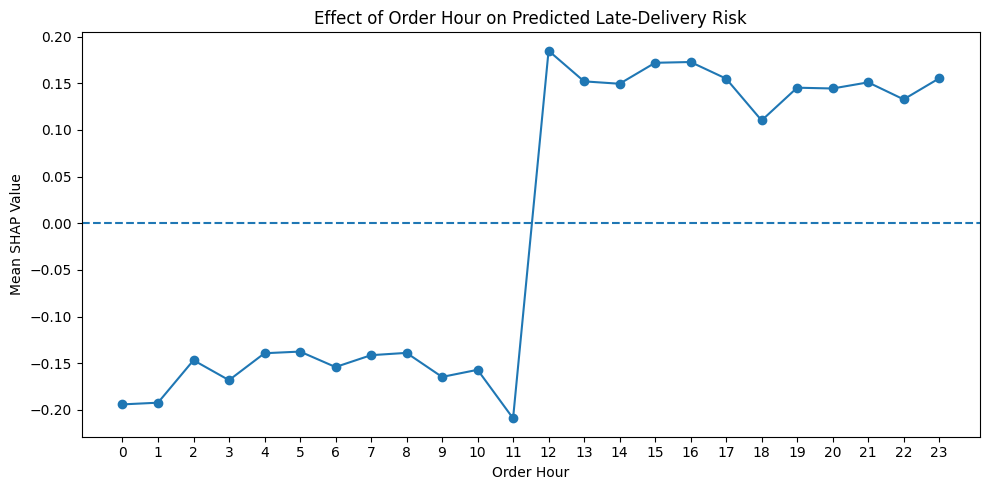

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    order_hour_effect["Order Hour"],
    order_hour_effect["Mean_SHAP"],
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Order Hour")
plt.ylabel("Mean SHAP Value")
plt.title(
    "Effect of Order Hour on Predicted Late-Delivery Risk"
)

plt.xticks(range(0, 24))

plt.tight_layout()
plt.show()

In [43]:
hour_target_audit = pd.DataFrame({
    "order_hour": X_train_raw["order_hour"],
    "Late_delivery_risk": y_train
})

hour_target_summary = (
    hour_target_audit
    .groupby("order_hour")
    .agg(
        Late_Delivery_Rate=(
            "Late_delivery_risk",
            "mean"
        ),
        Rows=(
            "Late_delivery_risk",
            "size"
        )
    )
    .reset_index()
)

display(
    hour_target_summary.style.format({
        "Late_Delivery_Rate": "{:.4f}"
    })
)

,order_hour,Late_Delivery_Rate,Rows
0,0,0.5132,4671
1,1,0.5219,4507
2,2,0.5257,4535
3,3,0.5249,4471
4,4,0.5150,4602
5,5,0.5162,4618
6,6,0.4976,4254
7,7,0.5270,4484
8,8,0.5018,4518
9,9,0.5380,4541


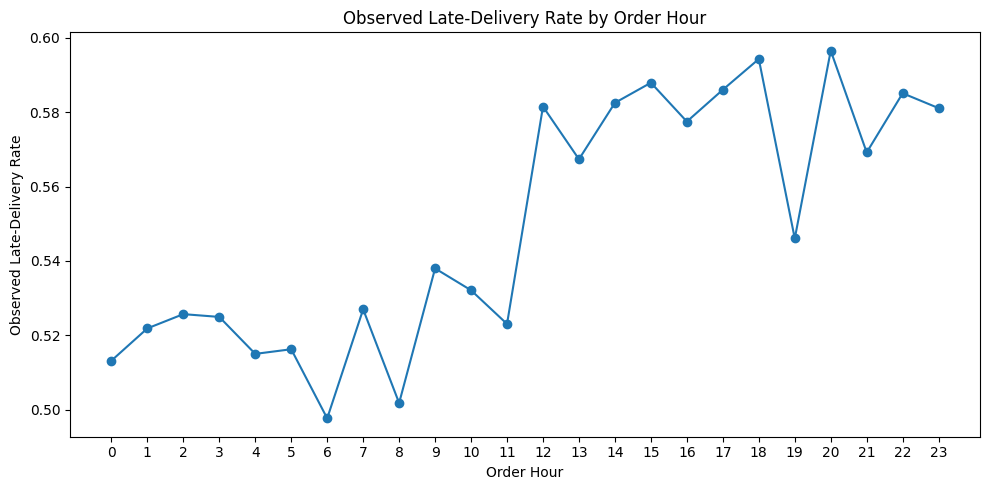

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    hour_target_summary["order_hour"],
    hour_target_summary["Late_Delivery_Rate"],
    marker="o"
)

plt.xlabel("Order Hour")
plt.ylabel("Observed Late-Delivery Rate")
plt.title("Observed Late-Delivery Rate by Order Hour")

plt.xticks(range(24))

plt.tight_layout()
plt.show()

### Order-Time Effect

SHAP analysis showed a clear time-of-day pattern. Orders placed before
12:00 generally received negative SHAP contributions, while orders placed
from approximately 12:00 onward received positive contributions toward
late-delivery predictions.

This pattern was also visible directly in the training data. Observed
late-delivery rates were generally lower during hours 00–11 and higher
during hours 12–23, indicating that the model was capturing a genuine
descriptive pattern in the dataset rather than an isolated model artifact.

However, this relationship should be interpreted as an association rather
than a causal effect. Because the dataset spans multiple geographic markets,
the operational meaning and timezone consistency of the recorded order hour
should also be considered a limitation.

## Key Findings

### 1. Shipping Service Was the Dominant Predictive Signal

Shipping Mode and Days for shipment (scheduled) were the two most influential
features in the model.

Further analysis showed that these variables had a deterministic one-to-one
relationship:

- Same Day = 0 scheduled days
- First Class = 1 scheduled day
- Second Class = 2 scheduled days
- Standard Class = 4 scheduled days

Therefore, these variables represent the same underlying shipping-service
configuration and should not be interpreted as independent effects.

SHAP analysis showed that First Class / 1-day shipments pushed predictions
most strongly toward late-delivery risk, while Standard Class / 4-day
shipments generally pushed predictions toward lower risk.

### 2. Transaction Type Provided Secondary Signal

Transaction Type also influenced predictions.

TRANSFER transactions generally pushed predictions toward lower
late-delivery risk, while CASH, PAYMENT, and DEBIT produced smaller positive
contributions toward predicted late-delivery risk.

### 3. Order Hour Showed a Clear Time-of-Day Pattern

Orders placed before approximately 12:00 generally produced negative SHAP
contributions, while orders placed from 12:00 onward produced positive
contributions toward late-delivery risk.

This pattern was also visible directly in the training data, where observed
late-delivery rates were generally lower before noon and higher after noon.

These relationships are descriptive associations captured by the model and
should not be interpreted as causal effects.

In [46]:
# Secondary order-level evaluation
order_test_results = pd.DataFrame(
    index=X_test_encoded.index
)

order_test_results["Order Id"] = test_df.loc[
    X_test_encoded.index,
    "Order Id"
]

order_test_results["Actual"] = y_test.loc[
    X_test_encoded.index
]

order_test_results["Probability"] = test_prob


# One prediction per order:
# average probabilities across line-item rows
order_level_results = (
    order_test_results
    .groupby("Order Id")
    .agg(
        Actual=("Actual", "first"),
        Probability=("Probability", "mean"),
        Line_Items=("Actual", "size")
    )
    .reset_index()
)


# Apply the SAME locked threshold
order_level_results["Prediction"] = (
    order_level_results["Probability"]
    >= selected_threshold
).astype(int)


# Metrics
order_auc = roc_auc_score(
    order_level_results["Actual"],
    order_level_results["Probability"]
)

order_accuracy = accuracy_score(
    order_level_results["Actual"],
    order_level_results["Prediction"]
)

order_precision = precision_score(
    order_level_results["Actual"],
    order_level_results["Prediction"]
)

order_recall = recall_score(
    order_level_results["Actual"],
    order_level_results["Prediction"]
)

order_f1 = f1_score(
    order_level_results["Actual"],
    order_level_results["Prediction"]
)


print("ORDER-LEVEL TEST RESULTS")
print("------------------------")

print(
    "Number of test orders:",
    len(order_level_results)
)

print(f"ROC-AUC:   {order_auc:.4f}")
print(f"Accuracy:  {order_accuracy:.4f}")
print(f"Precision: {order_precision:.4f}")
print(f"Recall:    {order_recall:.4f}")
print(f"F1-score:  {order_f1:.4f}")

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        order_level_results["Actual"],
        order_level_results["Prediction"]
    )
)

ORDER-LEVEL TEST RESULTS
------------------------
Number of test orders: 13151
ROC-AUC:   0.7728
Accuracy:  0.6822
Precision: 0.7114
Recall:    0.7071
F1-score:  0.7092

Confusion Matrix:
[[3873 2068]
 [2112 5098]]


### Order-Level Robustness Check

The dataset contains multiple line-item records for some orders. Although
the train, validation, and test partitions were separated by Order ID to
prevent cross-partition leakage, row-level evaluation can give greater
weight to orders containing more line items.

As a robustness check, predicted probabilities were averaged within each
Order ID so that every test order contributed exactly once to evaluation.

- Row-level test ROC-AUC: **0.7710**
- Order-level test ROC-AUC: **0.7728**
- Order-level precision: **0.7114**
- Order-level recall: **0.7071**
- Order-level F1-score: **0.7092**

The close agreement between row-level and order-level performance indicates
that the final conclusions are not being driven by repeated line-item rows
from larger orders.

## Limitations

Although the final model produced stable validation and test performance,
several limitations should be considered when interpreting the results.

### 1. Random Grouped Split Instead of Temporal Validation

The train, validation, and test sets were separated by Order ID, which
prevents the same order from appearing across partitions.

However, the split was random across the available time period rather than
strictly chronological. Therefore, the reported performance estimates
generalization to unseen orders drawn from a similar overall population, not
necessarily performance on future time periods.

### 2. Row-Level Modeling

The model was trained on line-item records, and some orders contain multiple
rows.

To reduce the impact of this structure, Order ID was used as the grouping
unit during splitting, and a secondary order-level evaluation was performed
by averaging probabilities within each order.

The order-level ROC-AUC of **0.7728** closely matched the row-level ROC-AUC
of **0.7710**.

### 3. Correlated Shipping Features

`Shipping Mode` and `Days for shipment (scheduled)` had a deterministic
one-to-one relationship in this dataset.

Their feature importance and SHAP contributions should therefore be viewed as
shared information about the same shipping-service configuration rather than
as independent effects.

### 4. Interpretation Is Associational

SHAP explains how features influence the fitted model's predictions, but it
does not establish causal relationships.

For example, the observed associations involving shipping mode, transaction
type, and order hour should not be interpreted as evidence that changing those
features would directly cause delivery performance to improve or worsen.

### 5. Operational Feature Availability

This project assumes prediction around the order-placement / pre-dispatch
stage. In a production system, every retained feature would need to be
verified to ensure that it is genuinely available and reliable at the exact
time a prediction is generated.

## Conclusion

This project developed a leakage-aware machine learning pipeline for
predicting late-delivery risk in supply-chain orders.

A major part of the work involved designing a reliable evaluation strategy.
Orders were separated across training, validation, and test sets by
`Order ID`, learned preprocessing was restricted to the training data,
and future-information features were removed before modeling.

Among the evaluated algorithms, Gradient Boosting achieved the strongest
validation performance. After limited hyperparameter tuning and validation-based
threshold selection, the final model achieved:

- **Test ROC-AUC: 0.7710**
- **Precision: 0.7076**
- **Recall: 0.7058**
- **F1-score: 0.7067**

A secondary evaluation in which each order contributed only once produced an
order-level ROC-AUC of **0.7728**, supporting the stability of the result.

Model interpretation showed that shipping-service configuration was the
dominant predictive signal, while transaction type and order hour provided
additional information.

Overall, the project demonstrates not only predictive modeling, but also the
importance of leakage prevention, group-aware evaluation, validation-based
decision making, and careful interpretation of model behavior.